## Creating Project

In [49]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import time
from tensorflow import keras
from tensorflow.keras import layers
import os

## Loading Dataset

In [50]:
(train_images,train_labels),(test_images,test_labels) =tf.keras.datasets.mnist.load_data()

The training and testing datasets are loaded into separate numpy arrays. As we are interested in generating a single digit, say 9, we will extract all images containing 9 from the train dataset.



In [51]:
digit9_images = []
for i in range(len(train_images)):
    if train_labels[i] == 9:
        digit9_images.append(train_images[i])
train_images = np.array(digit9_images)
train_images.shape

(5949, 28, 28)

The shape is (5949, 28, 28). Thus, we have 5949 images of size 28x28. It is a huge repository. Our model will try to produce images of this size, matching the looks of these images.

You can verify that you have images only for digit 9 by printing a few

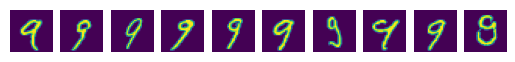

In [52]:
n = 10
f = plt.figure()
for i in range(n):
    f.add_subplot(1, n, i + 1)
    plt.subplot(1, n, i+1 ).axis("off")
    plt.imshow(train_images[i])
plt.show()

## Preparing Dataset

In [53]:
train_images[0].shape

(28, 28)

In [54]:
train_images = train_images.reshape (train_images.shape[0], 28, 28, 1).astype('float32')

In [55]:
train_images[0].shape

(28, 28, 1)

- As each color value in the image is in the range of 0 through 256, we
normalize these values to the scale of –1 to 1 for better learning
- The mean
value is 127.5, and thus the following equation will normalize the values in
the range –1 to +1. 
- You could have alternatively chosen 255 to normalize
the values between 0 and 1
 

In [56]:
train_images = (train_images - 127.5) / 127.5

In [57]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(train_images.shape[0]).batch(32)

In [58]:
train_dataset

<BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>

## Defining Generator Model

- The generator’s purpose is to create images containing digit 9 which look similar to the images in our training dataset

In [59]:
gen_model = tf.keras.Sequential()
gen_model.add(tf.keras.layers.Dense(7*7*256,use_bias=False,input_shape=(100,)))

gen_model.add(tf.keras.layers.BatchNormalization())
gen_model.add(tf.keras.layers.LeakyReLU())
gen_model.add(tf.keras.layers.Reshape((7, 7, 256)))

gen_model.add(tf.keras.layers.Conv2DTranspose
    (128, (5, 5),
    strides=(1, 1),
    padding='same',
    use_bias=False))

gen_model.add(tf.keras.layers.BatchNormalization())
gen_model.add(tf.keras.layers.LeakyReLU())


gen_model.add(tf.keras.layers.Conv2DTranspose
    (64, (5, 5),
    strides=(2, 2),
    padding='same',
    use_bias=False))
gen_model.add(tf.keras.layers.BatchNormalization())
gen_model.add(tf.keras.layers.LeakyReLU())

gen_model.add(tf.keras.layers.Conv2DTranspose
    (1, (5, 5),
    strides=(2, 2),
    padding='same',
    use_bias=False,
    activation='tanh'))

In [60]:
# You will use the Keras sequential model for creating our generator
gen_model = tf.keras.Sequential()

You will add the Keras Dense layer as the first layer. Optionally, you could make Conv2D layer as your first layer.

In [61]:
gen_model.add(tf.keras.layers.Dense(7*7*256,use_bias=False,input_shape=(100,)))

- The input to this layer is specified as 100 because later on we will use a
noise vector of dimension 100 as an input to this GAN model.
- We will start
with an image size of 7x7 and keep upscaling it to a final destination size of
28x28. 
- The z-dimension 256 specifies the filters used for our image, which
eventually gets converted to 3 for our final image

- Next, we add a batch normalization layer to the model for providing stability

In [62]:
gen_model.add(tf.keras.layers.BatchNormalization())
gen_model.add(tf.keras.layers.LeakyReLU())

We add the activation layer as a leaky ReLU. We reshape the output to 7x7x256:

In [63]:
gen_model.add(tf.keras.layers.Reshape((7, 7, 256)))

We now use the Conv2D layer to upscale the generated image

In [64]:
gen_model.add(tf.keras.layers.Conv2DTranspose
    (128, (5, 5),
    strides=(1, 1),
    padding='same',
    use_bias=False))

- The first parameter is the dimensionality of the output space, that is,
the number of output filters in the convolution. The second parameter
is the kernel_size that actually specifies the height and width of the
convolution filter.
- The third parameter specifies the strides of the
convolution along the height and width. To understand strides, consider a
filter being moved across the image from left to right and top to bottom, 1
pixel at a time.This movement is referred to as the stride.
- With a stride of
(2, 2), the filter is moved 2 pixels on each side, upscaling the image by 2x2

- Since the stride is specified as (1, 1), the output of this layer will be
the image of size 7x7 – the same as its input.
-  The padding ensures that the
dimensions remain the same.
- The false value in the use_bias parameter
indicates that the layer does not use a bias vector.
- This layer is then
followed by the batch normalization and activation layers as before

In [65]:
gen_model.add(tf.keras.layers.BatchNormalization())
gen_model.add(tf.keras.layers.LeakyReLU())

Next, we add the Conv2DTranspose layer with strides set to (2, 2) followed by the batch normalization and activation layers.

In [66]:
gen_model.add(tf.keras.layers.Conv2DTranspose
    (64, (5, 5),
    strides=(2, 2),
    padding='same',
    use_bias=False))
gen_model.add(tf.keras.layers.BatchNormalization())
gen_model.add(tf.keras.layers.LeakyReLU())

- The output image will now be of size 14x14

- We now add the last Conv2D layer with strides equal to (2, 2), thus further upscaling the image to size 28x28. This is our final desired image size.

In [67]:
gen_model.add(tf.keras.layers.Conv2DTranspose
    (1, (5, 5),
    strides=(2, 2),
    padding='same',
    use_bias=False,
    activation='tanh'))

In [68]:
gen_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 12544)             1254400   
                                                                 
 batch_normalization_9 (Batc  (None, 12544)            50176     
 hNormalization)                                                 
                                                                 
 leaky_re_lu_11 (LeakyReLU)  (None, 12544)             0         
                                                                 
 reshape_3 (Reshape)         (None, 7, 7, 256)         0         
                                                                 
 conv2d_transpose_9 (Conv2DT  (None, 7, 7, 128)        819200    
 ranspose)                                                       
                                                                 
 batch_normalization_10 (Bat  (None, 7, 7, 128)       

## Testing Generator

You will test the generator with a random input vector and display it on the console using the following code:



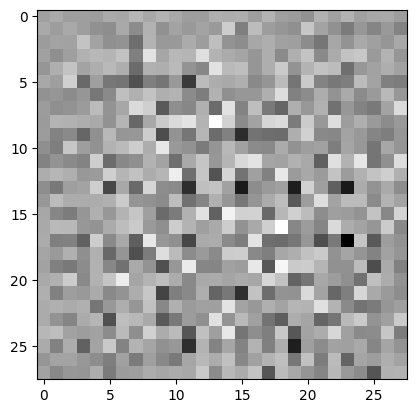

In [69]:
noise = tf.random.normal([1, 100])
#giving random input vector
generated_image = gen_model(noise, training=False)
plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [70]:
generated_image.shape

TensorShape([1, 28, 28, 1])

- The output indicates that the image has dimensions of 28x28, as desired by us. Next, we will define the discriminator

## Defining Discriminator Model

We define our discriminator as follows

In [71]:
discri_model = tf.keras.Sequential()
discri_model.add(tf.keras.layers.Conv2D
    (64, (5, 5),
    strides=(2, 2),
    padding='same',
    input_shape=[28, 28, 1]))

discri_model.add(tf.keras.layers.LeakyReLU())
discri_model.add(tf.keras.layers.Dropout(0.3))
discri_model.add(tf.keras.layers.Conv2D
    (128, (5, 5),
    strides=(2, 2),
    padding='same'))

discri_model.add(tf.keras.layers.LeakyReLU())
discri_model.add(tf.keras.layers.Dropout(0.3))
discri_model.add(tf.keras.layers.Flatten())
discri_model.add(tf.keras.layers.Dense(1))

- The discriminator uses just two convolutional layers.
- The output of the
last convolutional layer is of type (batch size, height, width, filters).
- The
Flatten layer in our network flattens this output to feed it to our last Dense
layer in the network.

In [72]:
discri_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 14, 14, 64)        1664      
                                                                 
 leaky_re_lu_14 (LeakyReLU)  (None, 14, 14, 64)        0         
                                                                 
 dropout_2 (Dropout)         (None, 14, 14, 64)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 7, 7, 128)         204928    
                                                                 
 leaky_re_lu_15 (LeakyReLU)  (None, 7, 7, 128)         0         
                                                                 
 dropout_3 (Dropout)         (None, 7, 7, 128)         0         
                                                                 
 flatten_1 (Flatten)         (None, 6272)             

## Testing Discriminator

- You may test the discriminator by feeding it with our earlier generated image.

In [73]:
decision = discri_model(generated_image)

In [74]:
decision

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.00038828]], dtype=float32)>

- The discriminator will give a negative value if the image is fake and
a positive value if it is real. Print the discriminator’s decision for this test
image.

- The decision value is 0.0033, a positive integer indicating that the
image is real.

-  A maximum value of 1 tells us that the model is sure about
the image being real.

- If you generate another image using our generator
and test the output of the discriminator, you may get a negative result.

- This
is because we have not yet trained our generator and discriminator on
some datasets

## Defining Loss Functions

In [75]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(generated_output):
    return cross_entropy(tf.ones_like(generated_output),generated_output)


def discriminator_loss(real_output,generated_output):
# compute loss considering the image is real [1,1,...,1]
    real_loss = cross_entropy(tf.ones_like(real_output),real_output)
    # compute loss considering the image is fake[0,0,...,0]
    generated_loss = cross_entropy(tf.zeros_like(generated_output),generated_output)
    # compute total loss
    total_loss = real_loss + generated_loss
    return total_loss

gen_optimizer = tf.optimizers.Adam(1e-4)
discri_optimizer = tf.optimizers.Adam(1e-4)

epoch_number = 0
EPOCHS = 100
noise_dim = 100
seed = tf.random.normal([1, noise_dim])


checkpoint_dir ='Checkpoint'
checkpoint_prefix =os.path.join(checkpoint_dir, "ckpt")

checkpoint = tf.train.Checkpoint(generator_optimizer = gen_optimizer,
discriminator_optimizer=discri_optimizer,generator= gen_model,discriminator = discri_model)

We will now define the loss function for our generator and discriminator.

In [76]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


- We use Keras’s binary cross-entropy function for our purpose. Note that we have two classes – one (1) for a real image and the other (0) for a fake one. We compute our loss for both these classes, and thus it makes our problem a binary classification problem. Thus, we use a binary cross-entropy for the loss function






We define a function to compute the generator loss as follos

In [77]:
def generator_loss(generated_output):
    return cross_entropy(tf.ones_like(generated_output),generated_output)

In [78]:
def discriminator_loss(real_output,generated_output):
# compute loss considering the image is real [1,1,...,1]
    real_loss = cross_entropy(tf.ones_like(real_output),real_output)
    # compute loss considering the image is fake[0,0,...,0]
    generated_loss = cross_entropy(tf.zeros_like(generated_output),generated_output)
    # compute total loss
    total_loss = real_loss + generated_loss
    return total_loss

We now define the optimizers for both generator and discriminator, which are set to Adam for both.

In [79]:
gen_optimizer = tf.optimizers.Adam(1e-4)
discri_optimizer = tf.optimizers.Adam(1e-4)

## Defining Few Functions for Training

In [80]:
epoch_number = 0
EPOCHS = 100
noise_dim = 100
seed = tf.random.normal([1, noise_dim])


We will train the model for 100 epochs. You can always change this variable to your choice. A higher number of epochs would generate a better image for the digit 9, which we are trying to generate. The noise dimension is set to 100 which is used while creating the random image for our first input to the generator network. The seed is set to random data for one image

## Checkpoint Setup

As the training may take a long time, we provide the checkpoint facility in the training so that the intermediate states of the generator and discriminator are saved to a local file



In [81]:
checkpoint_dir ='Checkpoint'
checkpoint_prefix =os.path.join(checkpoint_dir, "ckpt")

In [82]:
checkpoint = tf.train.Checkpoint(generator_optimizer = gen_optimizer,
discriminator_optimizer=discri_optimizer,generator= gen_model,discriminator = discri_model)

## Model Training Step

In [83]:
def gradient_tuning(images):
    # create a noise vector.
    noise = tf.random.normal([16, noise_dim])

    # Use gradient tapes for automatic differentiation 
    with tf.GradientTape() as generator_tape, tf.GradientTape() as discriminator_tape: 

      # ask genertor to generate random images
      generated_images = gen_model(noise, training=True)

      # ask discriminator to evalute the real images and generate its output
      real_output = discri_model(images, training=True)

      # ask discriminator to do the evlaution on generated (fake) images
      fake_output = discri_model(generated_images, training=True)

      # calculate generator loss on fake data
      gen_loss = generator_loss(fake_output)

      # calculate discriminator loss as defined earlier
      disc_loss = discriminator_loss(real_output, fake_output)

    # calculate gradients for generator
    gen_gradients = generator_tape.gradient(gen_loss, 
                                               gen_model.trainable_variables)

    # calculate gradients for discriminator
    discri_gradients = discriminator_tape.gradient(disc_loss, 
                                        discri_model.trainable_variables)

    # use optimizer to process and apply gradients to variables
    gen_optimizer.apply_gradients(zip(gen_gradients, 
                                            gen_model.trainable_variables))
    
    # same as above to discriminator
    discri_optimizer.apply_gradients(
        zip(discri_gradients, 
            discri_model.trainable_variables))

We now write one more function for generating the image of digit 9, our desired output, and saving it

In [84]:
    def generate_and_save_images(model, epoch, test_input):
        # use a global count for tracking epochs in case of disconnection
        global epoch_number
        epoch_number = epoch_number + 1

        # set training to false to ensure inference mode
        predictions = model(test_input, training=False)

        # display and save image
        fig = plt.figure(figsize=(4,4))
        for i in range(predictions.shape[0]):
            plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
            plt.axis('off')
        plt.savefig('image_at_epoch_{:01d}.png'.format(epoch_number))
        plt.show()

## Model Training

In [85]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      gradient_tuning(image_batch)
    
    # Produce images as we go
    generate_and_save_images(gen_model,
                             epoch + 1,
                             seed)
    
    # save checkpoint data
    checkpoint.save(file_prefix = checkpoint_prefix)
    print ('Time for epoch {} is {} sec'.format(epoch + 1, 
                                                time.time()-start))

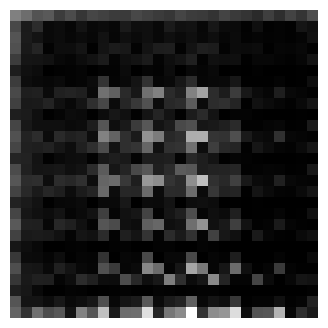

Time for epoch 1 is 10.974467039108276 sec


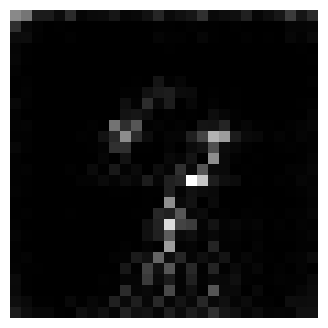

Time for epoch 2 is 10.866784811019897 sec


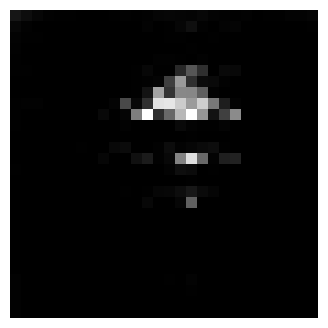

Time for epoch 3 is 11.115885734558105 sec


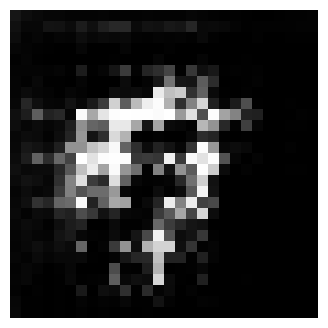

Time for epoch 4 is 11.614908695220947 sec


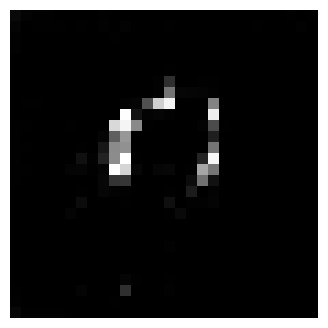

Time for epoch 5 is 13.894378423690796 sec


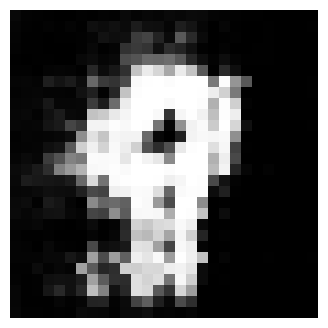

Time for epoch 6 is 13.984331846237183 sec


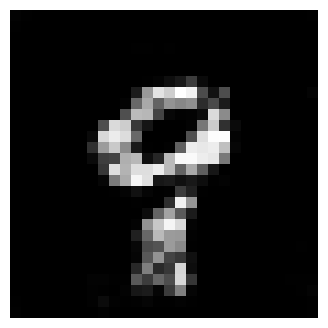

Time for epoch 7 is 14.044044733047485 sec


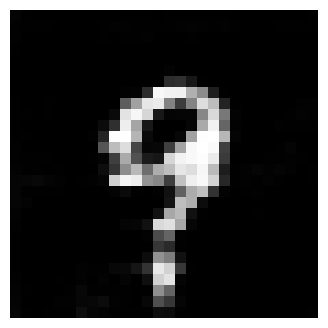

Time for epoch 8 is 13.794660806655884 sec


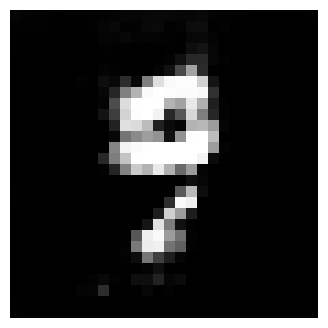

Time for epoch 9 is 13.971163511276245 sec


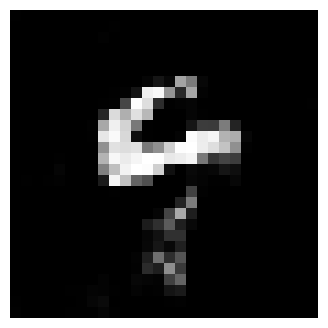

Time for epoch 10 is 14.427629232406616 sec


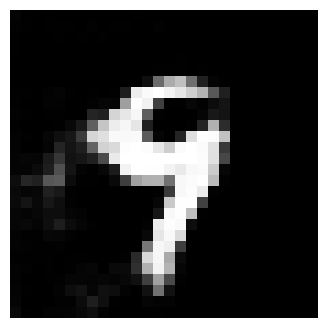

Time for epoch 11 is 13.974609136581421 sec


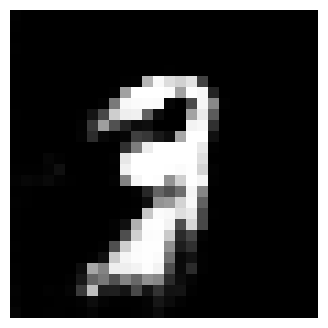

Time for epoch 12 is 14.154863834381104 sec


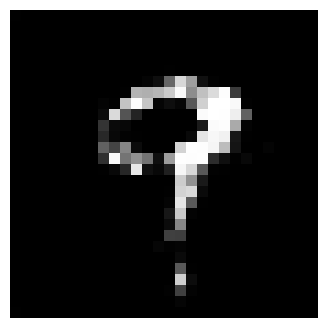

Time for epoch 13 is 14.00766134262085 sec


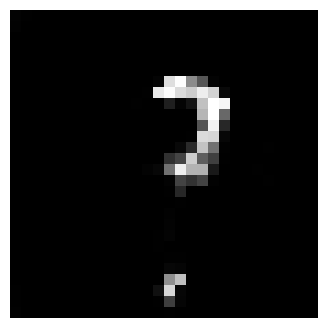

Time for epoch 14 is 13.959508419036865 sec


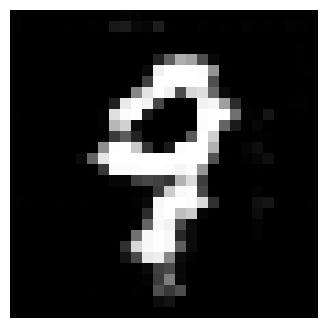

Time for epoch 15 is 14.096852779388428 sec


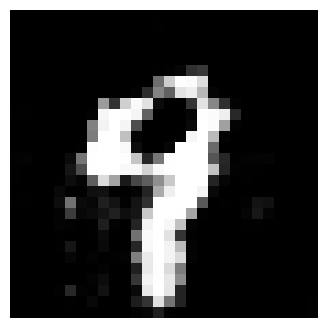

Time for epoch 16 is 13.983256101608276 sec


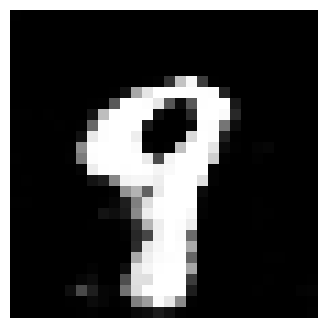

Time for epoch 17 is 13.973740339279175 sec


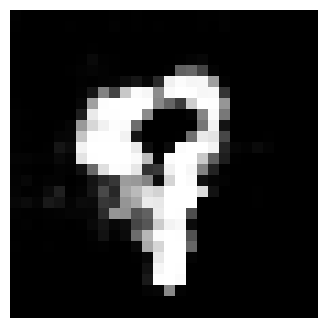

Time for epoch 18 is 13.937154531478882 sec


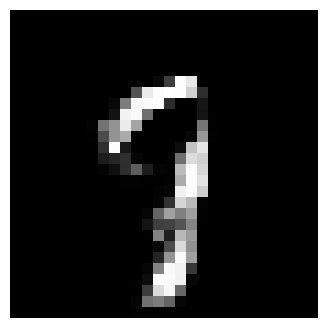

Time for epoch 19 is 13.769029140472412 sec


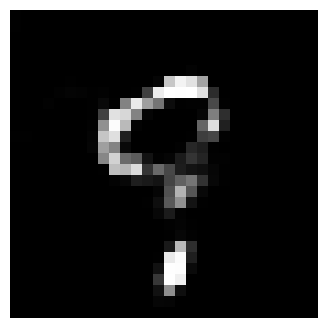

Time for epoch 20 is 13.96367621421814 sec


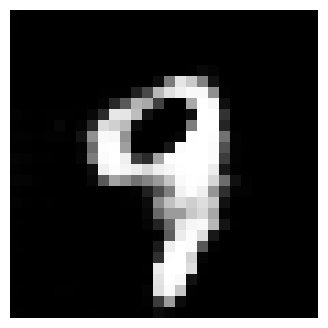

Time for epoch 21 is 14.051984786987305 sec


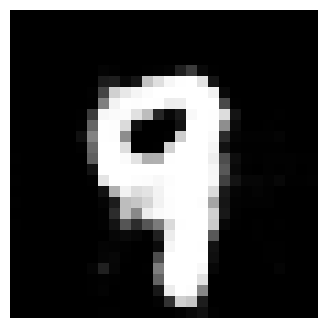

Time for epoch 22 is 14.627489805221558 sec


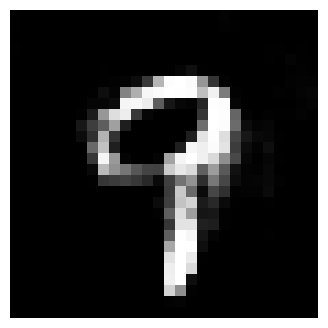

Time for epoch 23 is 14.416975975036621 sec


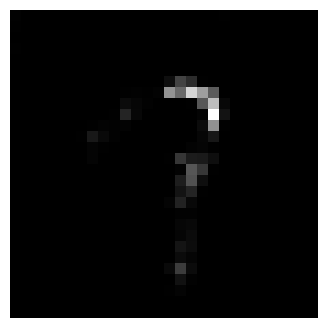

Time for epoch 24 is 14.11549687385559 sec


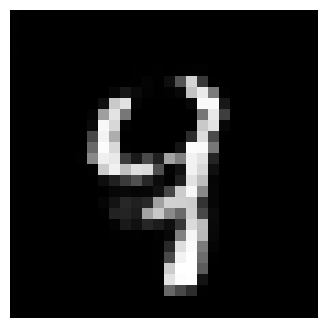

Time for epoch 25 is 14.648520469665527 sec


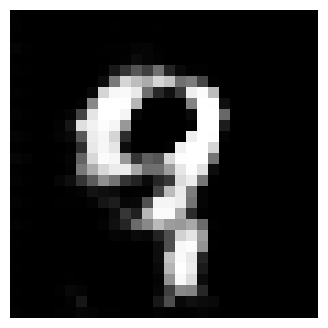

Time for epoch 26 is 14.988478660583496 sec


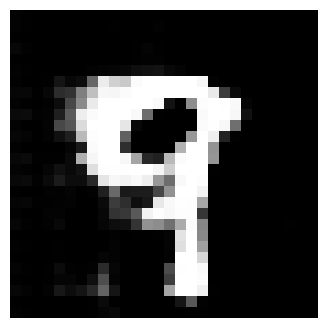

Time for epoch 27 is 14.323158502578735 sec


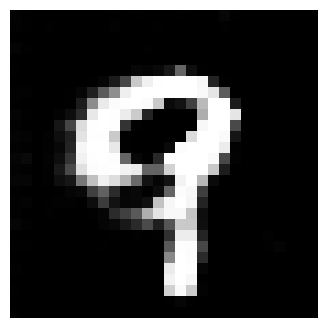

Time for epoch 28 is 14.397987604141235 sec


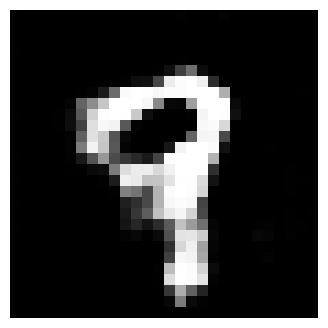

Time for epoch 29 is 14.172665119171143 sec


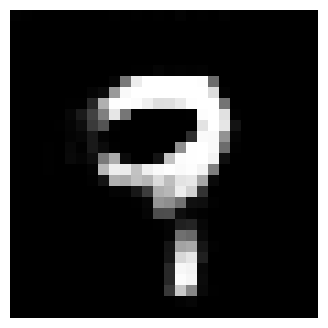

Time for epoch 30 is 14.289819717407227 sec


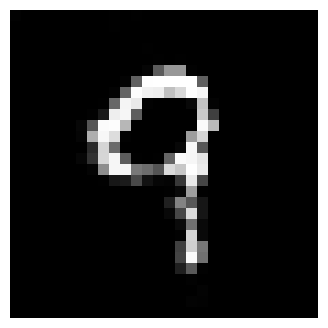

Time for epoch 31 is 15.317418336868286 sec


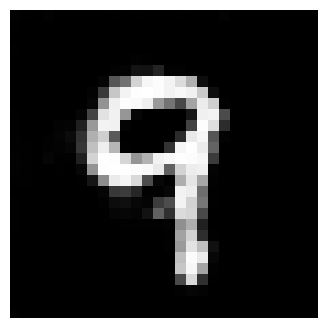

Time for epoch 32 is 15.556260824203491 sec


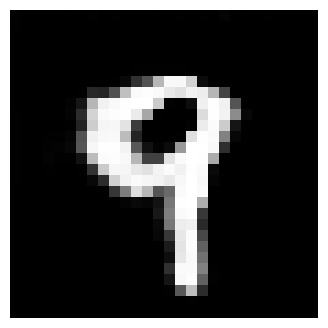

Time for epoch 33 is 15.828428030014038 sec


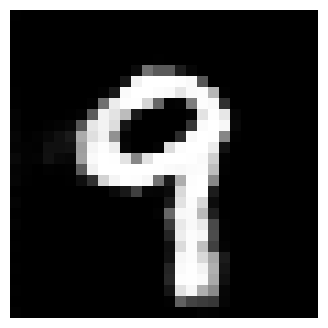

Time for epoch 34 is 15.195262432098389 sec


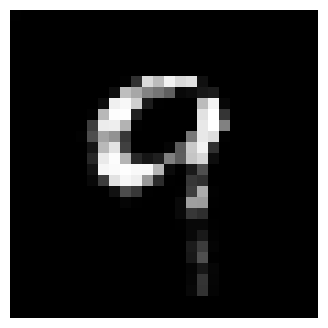

Time for epoch 35 is 15.463727474212646 sec


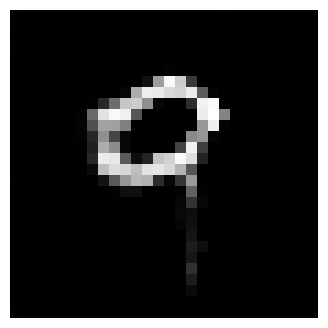

Time for epoch 36 is 16.04917597770691 sec


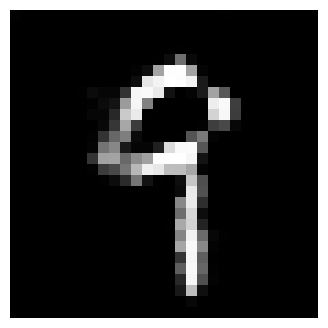

Time for epoch 37 is 16.813411712646484 sec


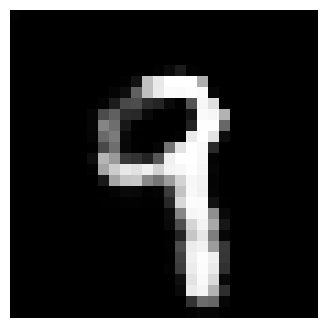

Time for epoch 38 is 15.898661375045776 sec


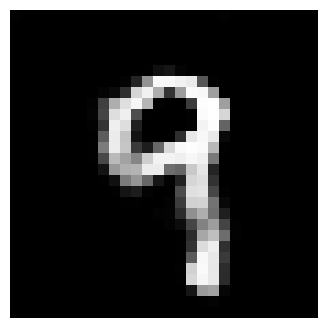

Time for epoch 39 is 13.832037687301636 sec


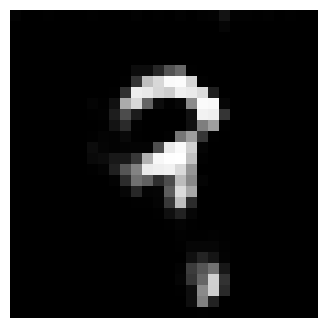

Time for epoch 40 is 13.826601266860962 sec


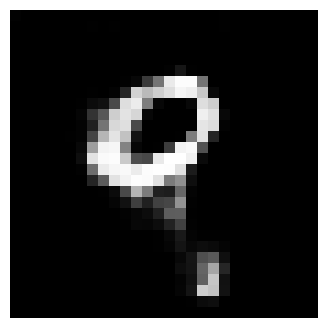

Time for epoch 41 is 13.978774070739746 sec


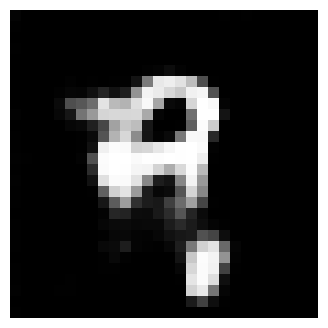

Time for epoch 42 is 13.927332401275635 sec


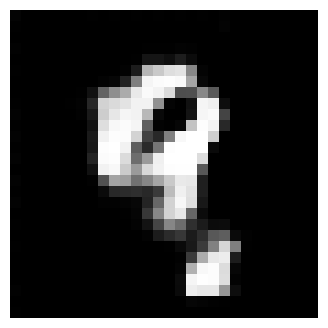

Time for epoch 43 is 13.913478374481201 sec


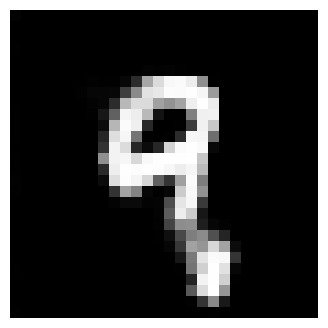

Time for epoch 44 is 13.896479606628418 sec


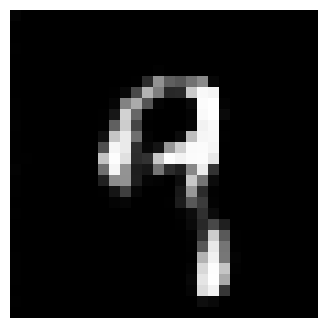

Time for epoch 45 is 14.047017812728882 sec


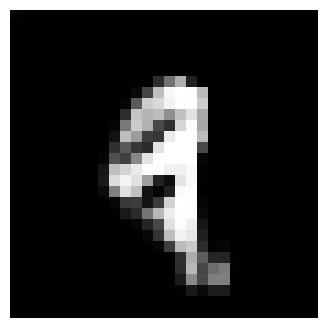

Time for epoch 46 is 13.976095199584961 sec


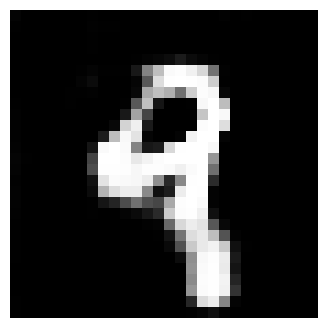

Time for epoch 47 is 14.168951511383057 sec


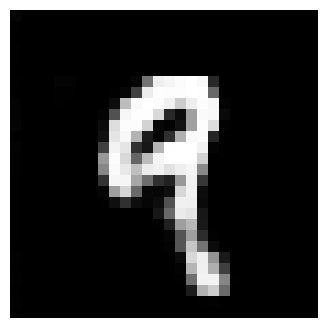

Time for epoch 48 is 14.013087272644043 sec


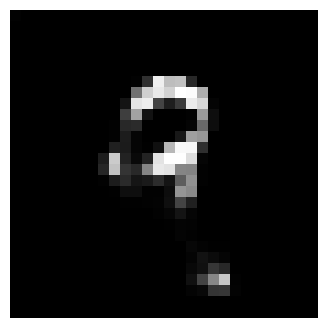

Time for epoch 49 is 14.098434448242188 sec


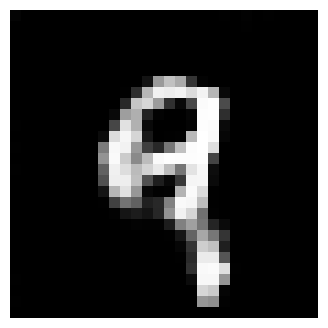

Time for epoch 50 is 14.207064390182495 sec


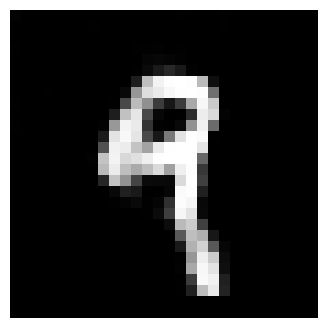

Time for epoch 51 is 13.987303733825684 sec


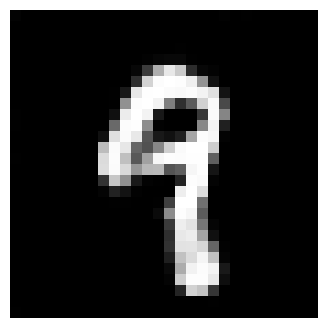

Time for epoch 52 is 14.027103185653687 sec


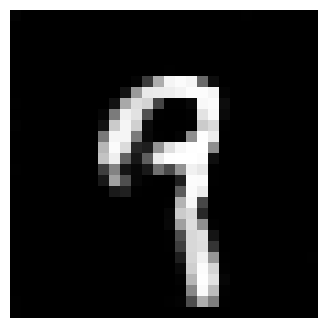

Time for epoch 53 is 14.110643863677979 sec


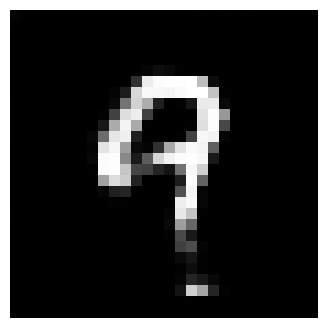

Time for epoch 54 is 14.08399748802185 sec


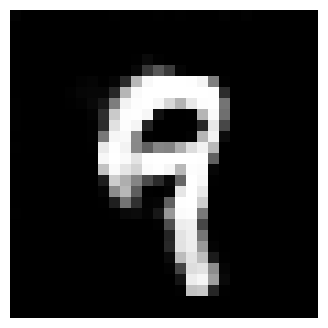

Time for epoch 55 is 14.085366487503052 sec


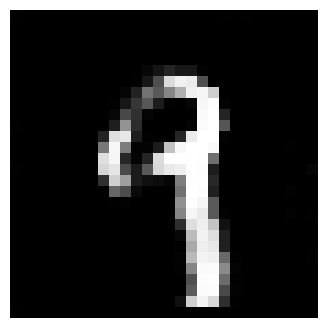

Time for epoch 56 is 14.08514404296875 sec


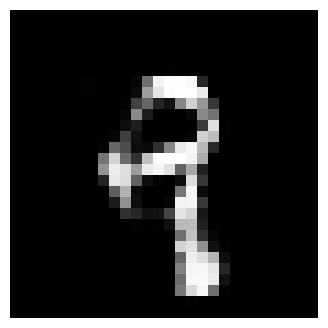

Time for epoch 57 is 13.866602182388306 sec


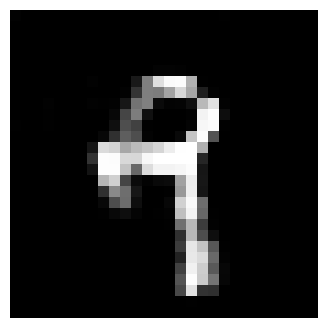

Time for epoch 58 is 14.022048473358154 sec


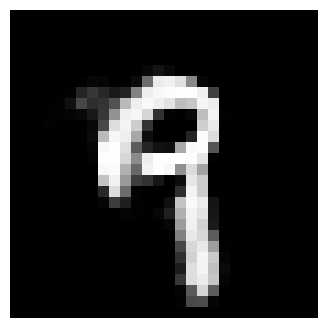

Time for epoch 59 is 13.872663974761963 sec


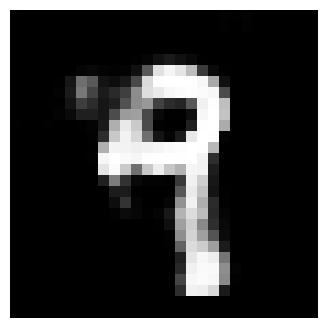

Time for epoch 60 is 14.091322660446167 sec


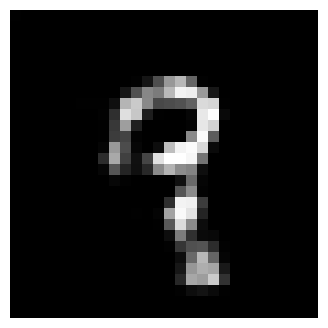

Time for epoch 61 is 14.051865339279175 sec


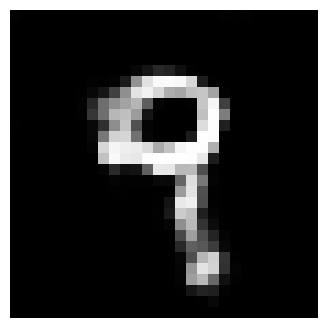

Time for epoch 62 is 14.013655424118042 sec


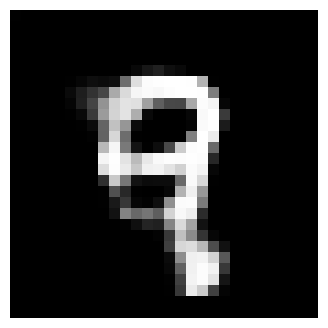

Time for epoch 63 is 14.194562196731567 sec


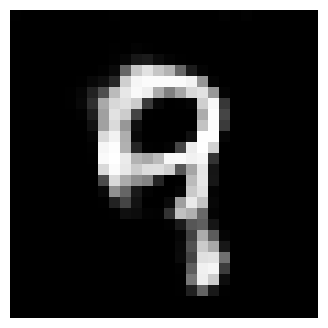

Time for epoch 64 is 14.275826454162598 sec


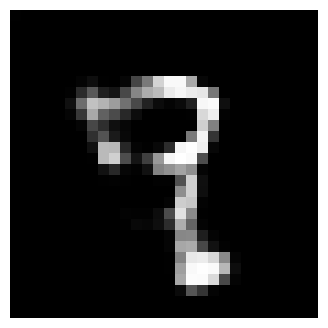

Time for epoch 65 is 13.931504249572754 sec


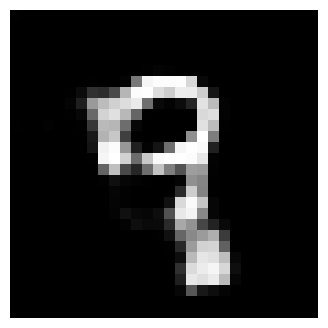

Time for epoch 66 is 14.195058584213257 sec


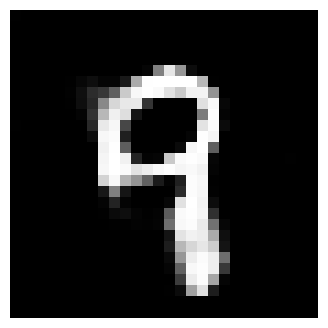

Time for epoch 67 is 14.201215505599976 sec


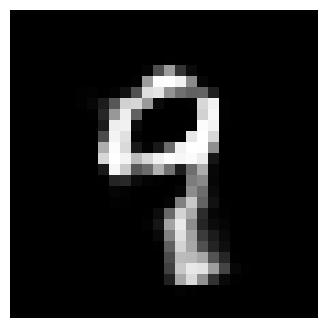

Time for epoch 68 is 14.10440731048584 sec


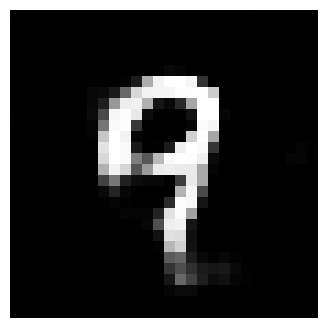

Time for epoch 69 is 14.331665515899658 sec


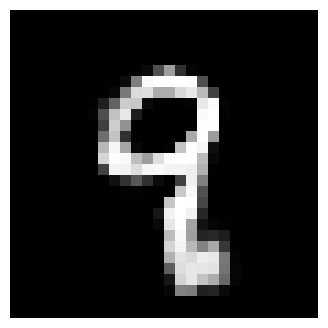

Time for epoch 70 is 14.179001092910767 sec


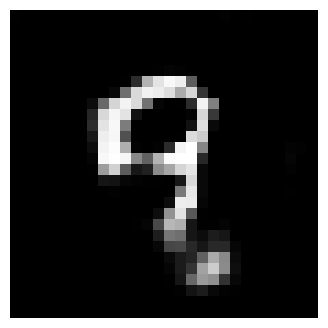

Time for epoch 71 is 14.000666856765747 sec


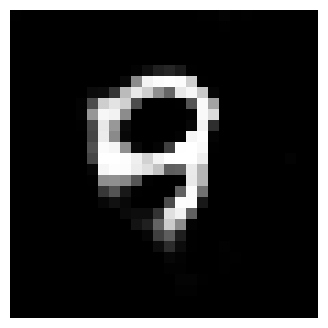

Time for epoch 72 is 14.031999349594116 sec


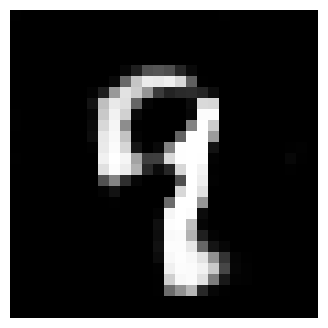

Time for epoch 73 is 14.120504140853882 sec


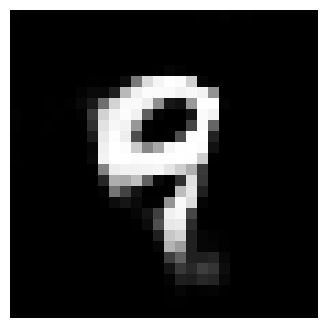

Time for epoch 74 is 14.039090871810913 sec


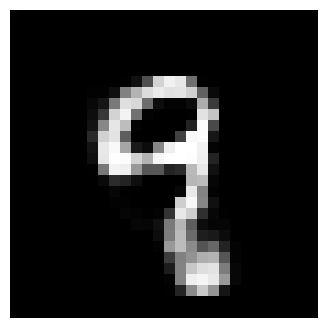

Time for epoch 75 is 13.940709829330444 sec


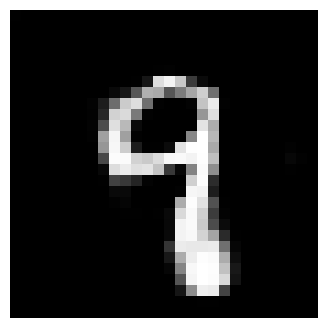

Time for epoch 76 is 14.144999265670776 sec


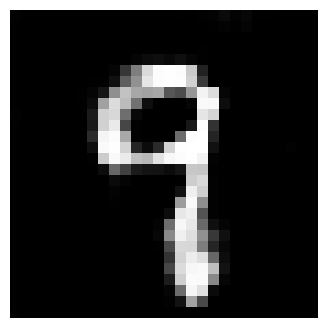

Time for epoch 77 is 14.256505966186523 sec


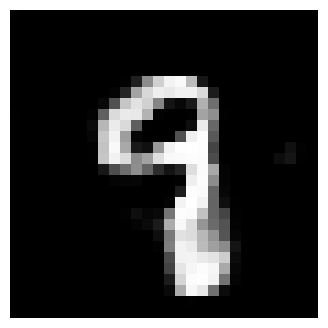

Time for epoch 78 is 14.17663025856018 sec


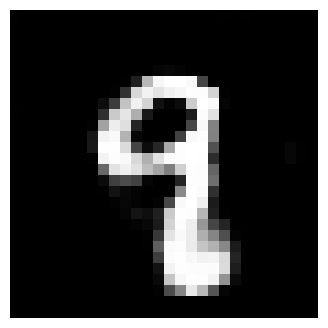

Time for epoch 79 is 14.02893614768982 sec


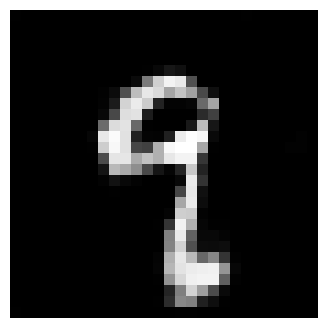

Time for epoch 80 is 14.100966691970825 sec


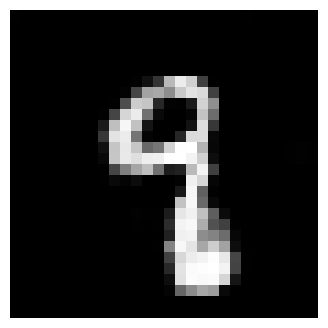

Time for epoch 81 is 14.066756010055542 sec


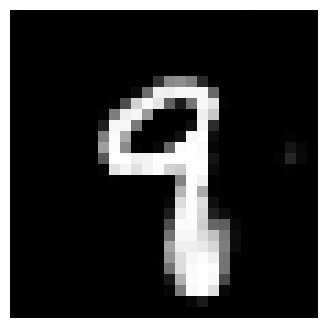

Time for epoch 82 is 14.098163604736328 sec


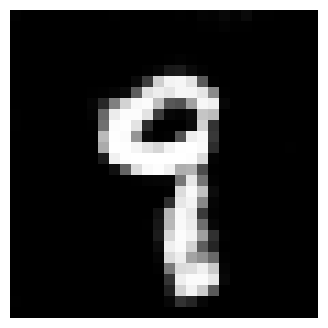

Time for epoch 83 is 14.133076190948486 sec


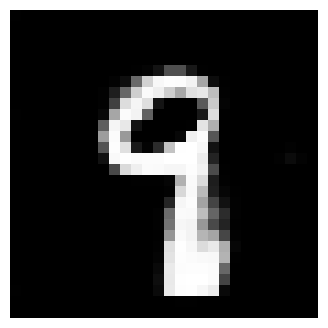

Time for epoch 84 is 14.185645580291748 sec


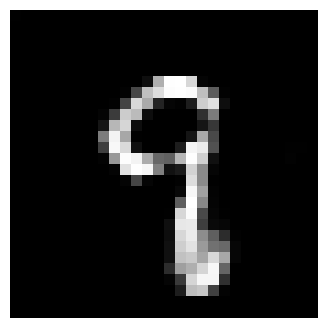

Time for epoch 85 is 14.165639638900757 sec


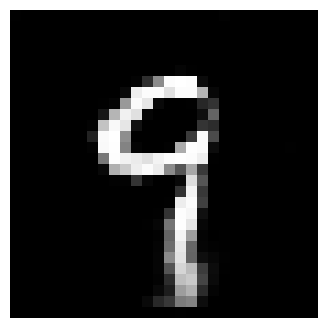

Time for epoch 86 is 14.008778095245361 sec


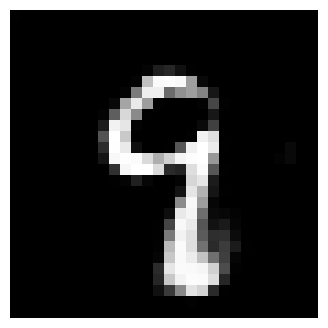

Time for epoch 87 is 14.73022985458374 sec


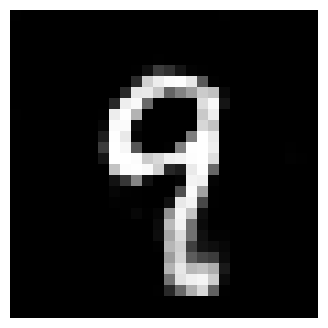

Time for epoch 88 is 14.2565598487854 sec


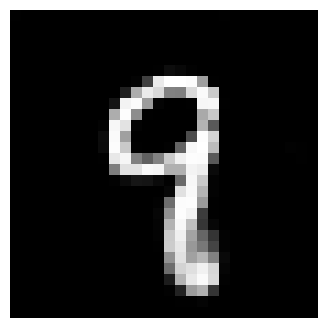

Time for epoch 89 is 16.860417127609253 sec


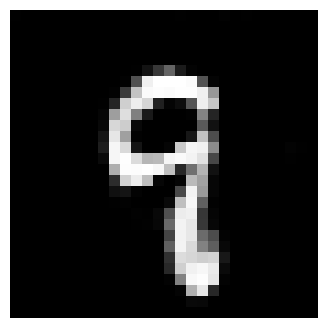

Time for epoch 90 is 17.00498652458191 sec


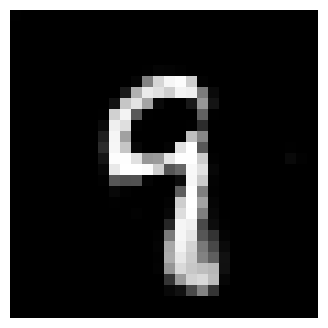

Time for epoch 91 is 14.753586292266846 sec


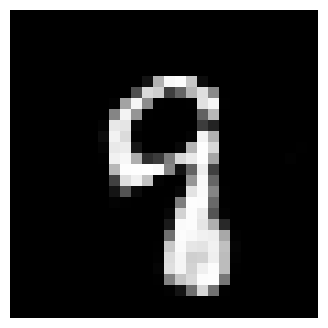

Time for epoch 92 is 15.140213012695312 sec


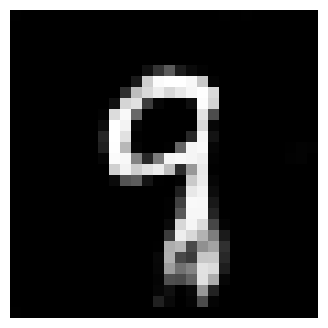

Time for epoch 93 is 15.183120489120483 sec


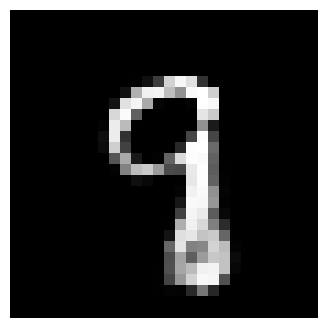

Time for epoch 94 is 14.616891384124756 sec


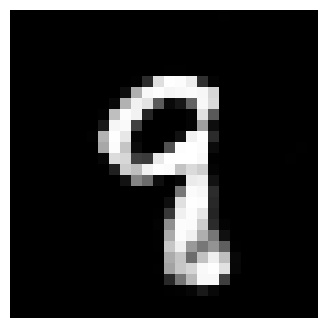

Time for epoch 95 is 14.672443389892578 sec


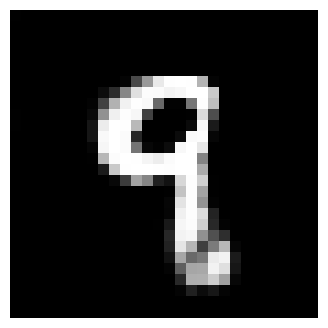

Time for epoch 96 is 14.919495105743408 sec


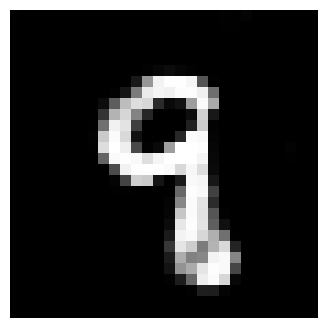

Time for epoch 97 is 14.796956539154053 sec


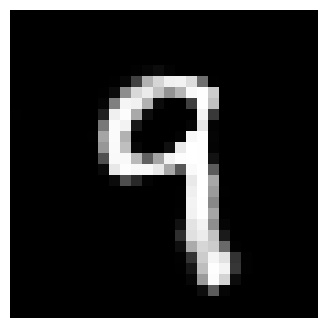

Time for epoch 98 is 14.20969557762146 sec


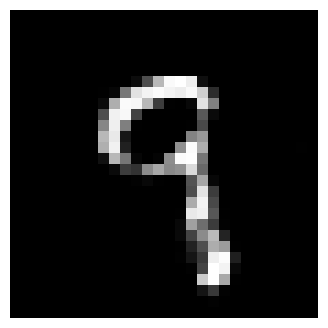

Time for epoch 99 is 14.377663135528564 sec


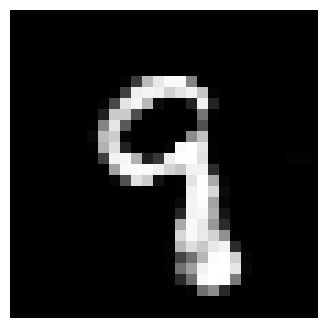

Time for epoch 100 is 14.816274881362915 sec


In [86]:
train(train_dataset,EPOCHS)

As the training progresses, the checkpoints are saved and the images are generated at each epoch. The images are displayed on the console and are also saved

As you can see from the output, the network is able to create an acceptable output just after 20/30 epochs, and at 70 and above, the quality is best

During training and in case of disconnection, you can restore the network state from a previous known checkpoint